### Tokenization

In [4]:
from pathlib import Path
from collections import Counter

In [202]:
project_root = Path.cwd().parents[0]
project_root

PosixPath('/home/dhiran/projects/deep-learning-from-scratch')

In [203]:
# Unicode point code  (The id of the character)
ord("h"), ord("😄")

(104, 128516)

In [204]:

list("Hello 😄".encode("utf-8"))

[72, 101, 108, 108, 111, 32, 240, 159, 152, 132]

In [2]:
# UTF - 8 Encoding (Unicode point code -> Bytes)
text = "Hi, my name is Dhiranjit 😄"
tokens = list(text.encode("utf-8"))

print("-------")
print(text)
print("Length:", len(text))
print("-------")
print(tokens)
print("Length:", len(tokens))



-------
Hi, my name is Dhiranjit 😄
Length: 26
-------
[72, 105, 44, 32, 109, 121, 32, 110, 97, 109, 101, 32, 105, 115, 32, 68, 104, 105, 114, 97, 110, 106, 105, 116, 32, 240, 159, 152, 132]
Length: 29


### Byte-pair Encoding

In [227]:
with open(project_root / "data/tiny_shakespeare.txt") as f:
    text = f.read()

tokens = list(text.encode("utf-8"))

print(len(text)) # len(text) == len(tokens) because everything is simple ascii characters here.
print(len(tokens))

1115394
1115394


In [228]:
# Finding the most frequent byte

counts = {}
for pair in zip(tokens, tokens[1:]):
    counts[pair] = counts.get(pair, 0) + 1

max(counts, key=counts.get)

(101, 32)

In [5]:
def pair_counts(tokens):
    return Counter(zip(tokens, tokens[1:]))

In [230]:
# Merge the most frequent token
def merge(tokens, pair, new_token):
    """Replace all occurrences of pair with new_token in tokens list."""
    result = []
    i = 0
    while i < len(tokens) - 1:
        if tokens[i] == pair[0] and tokens[i+1] == pair[1]:
            result.append(new_token)
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    result.append(tokens[-1]) # Appending the last token
    return result

In [231]:
# BPE training loop
from tqdm import tqdm

vocab_size = 1600
merges = {}
compression = []

original_length = len(tokens) # Before training

pbar = tqdm(range(vocab_size - 256), desc="BPE Training", unit="merge")

for i in pbar:
    counts = pair_counts(tokens)
    pair = max(counts, key=counts.get)

    new_token = 256 + i
    tokens = merge(tokens, pair, new_token)

    merges[pair] = new_token

    if i % 10 == 0:
        compression.append((new_token, len(tokens)))
        pbar.set_postfix(tokens=len(tokens))

BPE Training: 100%|██████████| 1344/1344 [02:17<00:00,  9.75merge/s, tokens=387220]


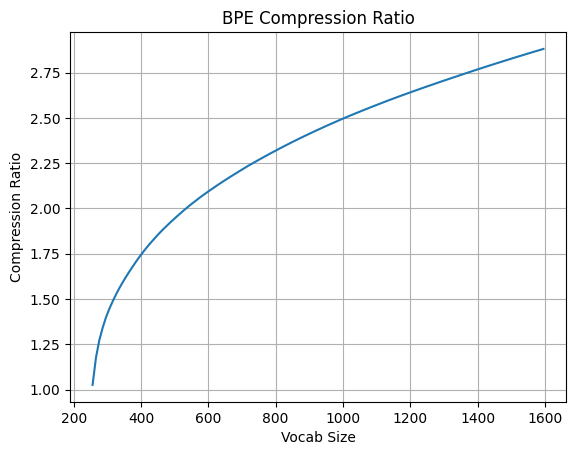

In [212]:
import matplotlib.pyplot as plt
vocab_sizes, token_counts = zip(*compression)
ratios = [original_length / t for t in token_counts]

plt.plot(vocab_sizes, ratios)
plt.xlabel("Vocab Size")
plt.ylabel("Compression Ratio")
plt.title("BPE Compression Ratio")
plt.grid(True)
plt.show()

In [ ]:
# Creating the vocab
vocab = {idx: bytes([idx]) for idx in range(256)}

for pair, token in merges.items():
    vocab[token] = vocab[pair[0]] + vocab[pair[1]] # Addition of two bytes objects

In [174]:
# decode bytes to string for readability
for token_id, token_bytes in vocab.items():
    print(f"{token_id} -> {token_bytes} -> {token_bytes.decode('utf-8', errors='replace')}")

0 -> b'\x00' ->  
1 -> b'\x01' -> 
2 -> b'\x02' -> 
3 -> b'\x03' -> 
4 -> b'\x04' -> 
5 -> b'\x05' -> 
6 -> b'\x06' -> 
7 -> b'\x07' -> 
8 -> b'\x08' ->
9 -> b'\t' -> 	
10 -> b'\n' -> 

11 -> b'\x0b' -> 
12 -> b'\x0c' -> 
13 -> b'\r' -> 
14 -> b'\x0e' -> 
15 -> b'\x0f' -> 
16 -> b'\x10' -> 
17 -> b'\x11' -> 
18 -> b'\x12' -> 
19 -> b'\x13' -> 
20 -> b'\x14' -> 
21 -> b'\x15' -> 
22 -> b'\x16' -> 
23 -> b'\x17' -> 
24 -> b'\x18' -> 
25 -> b'\x19' -> 
26 -> b'\x1a' -> 
27 -> b'\x1b' -> 
28 -> b'\x1c' -> 
29 -> b'\x1d' -> 
30 -> b'\x1e' -> 
31 -> b'\x1f' -> 
32 -> b' ' ->  
33 -> b'!' -> !
34 -> b'"' -> "
35 -> b'#' -> #
36 -> b'$' -> $
37 -> b'%' -> %
38 -> b'&' -> &
39 -> b"'" -> '
40 -> b'(' -> (
41 -> b')' -> )
42 -> b'*' -> *
43 -> b'+' -> +
44 -> b',' -> ,
45 -> b'-' -> -
46 -> b'.' -> .
47 -> b'/' -> /
48 -> b'0' -> 0
49 -> b'1' -> 1
50 -> b'2' -> 2
51 -> b'3' -> 3
52 -> b'4' -> 4
53 -> b'5' -> 5
54 -> b'6' -> 6
55 -> b'7' -> 7
56 -> b'8' -> 8
57 -> b'9' 

### Encoding & Decoding

In [215]:
def decode(ids):
    # given ids (list of intergers), return python string
    return b"".join([vocab[idx] for idx in ids]).decode("utf-8", errors="replace")


In [ ]:
ids = [356, 546, 346, 1000, 1200, 1356]

print(decode([128]))

�


In [222]:
merges

{(101, 32): 256,
 (116, 104): 257,
 (116, 32): 258,
 (115, 32): 259,
 (100, 32): 260,
 (44, 32): 261,
 (111, 117): 262,
 (101, 114): 263,
 (105, 110): 264,
 (121, 32): 265,
 (97, 110): 266,
 (58, 10): 267,
 (111, 114): 268,
 (111, 32): 269,
 (101, 110): 270,
 (10, 10): 271,
 (97, 114): 272,
 (32, 257): 273,
 (111, 110): 274,
 (108, 108): 275,
 (104, 97): 276,
 (44, 10): 277,
 (46, 271): 278,
 (105, 259): 279,
 (101, 115): 280,
 (121, 262): 281,
 (32, 115): 282,
 (116, 269): 283,
 (266, 260): 284,
 (111, 119): 285,
 (101, 97): 286,
 (32, 109): 287,
 (32, 119): 288,
 (111, 102): 289,
 (32, 104): 290,
 (264, 103): 291,
 (111, 109): 292,
 (32, 97): 293,
 (99, 104): 294,
 (257, 256): 295,
 (115, 116): 296,
 (32, 98): 297,
 (110, 111): 298,
 (105, 114): 299,
 (102, 268): 300,
 (118, 256): 301,
 (101, 261): 302,
 (105, 257): 303,
 (273, 256): 304,
 (115, 101): 305,
 (108, 105): 306,
 (84, 104): 307,
 (275, 32): 308,
 (114, 101): 309,
 (115, 258): 310,
 (97, 258): 311,
 (65, 110): 312,
 (73, 3

In [ ]:
def encode(text):
    tokens = list(text.encode("utf-8"))
    while len(tokens) > 2:
        counts = pair_counts(tokens)
        pair = min(counts, key=lambda p: merges.get(p, float("inf")))
        if pair not in merges:
            break
        
        idx = merges[pair]
        tokens = merge(tokens, pair, idx)
    return tokens

In [ ]:
len()

In [243]:
encode("Hello World")

[72, 389, 269, 87, 268, 108, 100]

In [244]:
decode([72, 389, 269, 87, 268, 108, 100])

'Hello World'

### Forced Regex

In [ ]:
import regex as re

gpt2pat = re.compile(
    r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
)


### We have not idea how to train the tokenizer properly.

### Special Tokens

In [14]:
{i: bytes([i]) for i in range(256)}

{0: b'\x00',
 1: b'\x01',
 2: b'\x02',
 3: b'\x03',
 4: b'\x04',
 5: b'\x05',
 6: b'\x06',
 7: b'\x07',
 8: b'\x08',
 9: b'\t',
 10: b'\n',
 11: b'\x0b',
 12: b'\x0c',
 13: b'\r',
 14: b'\x0e',
 15: b'\x0f',
 16: b'\x10',
 17: b'\x11',
 18: b'\x12',
 19: b'\x13',
 20: b'\x14',
 21: b'\x15',
 22: b'\x16',
 23: b'\x17',
 24: b'\x18',
 25: b'\x19',
 26: b'\x1a',
 27: b'\x1b',
 28: b'\x1c',
 29: b'\x1d',
 30: b'\x1e',
 31: b'\x1f',
 32: b' ',
 33: b'!',
 34: b'"',
 35: b'#',
 36: b'$',
 37: b'%',
 38: b'&',
 39: b"'",
 40: b'(',
 41: b')',
 42: b'*',
 43: b'+',
 44: b',',
 45: b'-',
 46: b'.',
 47: b'/',
 48: b'0',
 49: b'1',
 50: b'2',
 51: b'3',
 52: b'4',
 53: b'5',
 54: b'6',
 55: b'7',
 56: b'8',
 57: b'9',
 58: b':',
 59: b';',
 60: b'<',
 61: b'=',
 62: b'>',
 63: b'?',
 64: b'@',
 65: b'A',
 66: b'B',
 67: b'C',
 68: b'D',
 69: b'E',
 70: b'F',
 71: b'G',
 72: b'H',
 73: b'I',
 74: b'J',
 75: b'K',
 76: b'L',
 77: b'M',
 78: b'N',
 79: b'O',
 80: b'P',
 81: b'Q',
 82: b'R',
 83: b'